In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cropdata_updated.csv")

In [3]:
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [4]:
# drop these where result value is 2
before = len(df)
df = df[df['result'] != 2]
after = len(df)

print(f"Removed {before - after} rows")

Removed 1122 rows


In [5]:
df.shape

(15289, 7)

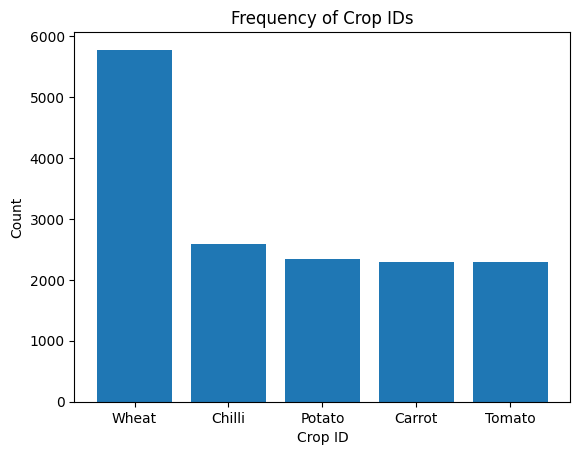

In [6]:
counts = df['crop ID'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Crop ID')
plt.ylabel('Count')
plt.title('Frequency of Crop IDs')
plt.show()

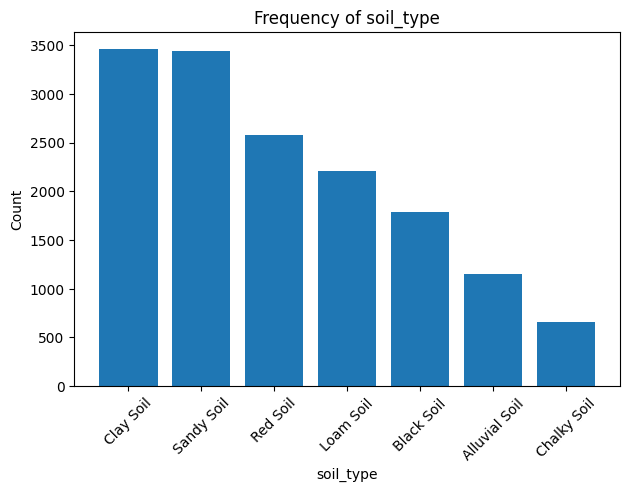

In [7]:
counts = df['soil_type'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('soil_type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Frequency of soil_type')
plt.show()

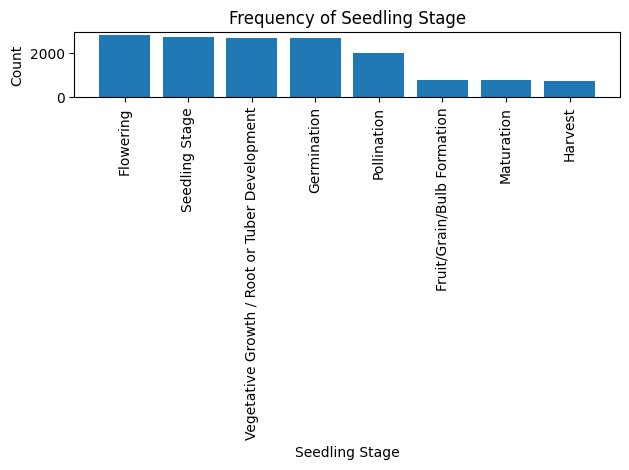

In [8]:
counts = df['Seedling Stage'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Seedling Stage')
plt.ylabel('Count')
plt.title('Frequency of Seedling Stage')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


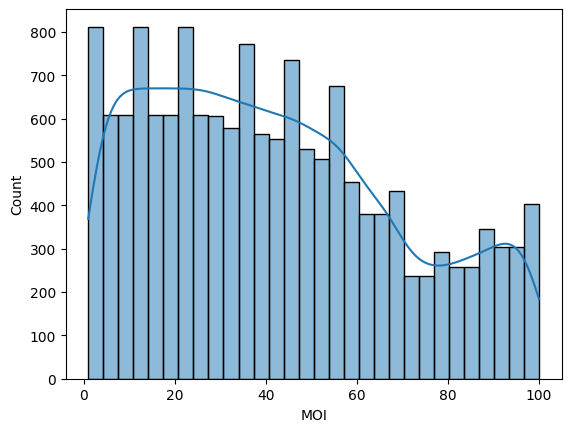

In [9]:
sns.histplot(data = df , x = 'MOI' , kde = True)
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


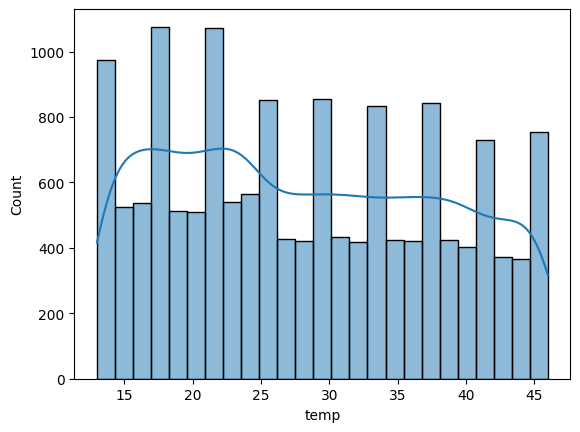

In [10]:
sns.histplot(data = df , x = 'temp' , kde = True)
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


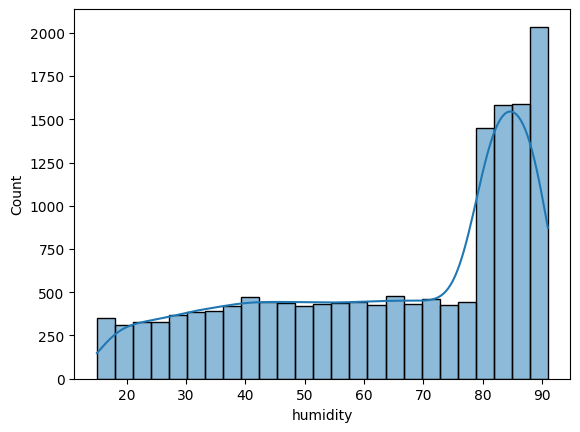

In [11]:
sns.histplot(data = df , x = 'humidity' , kde = True)
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


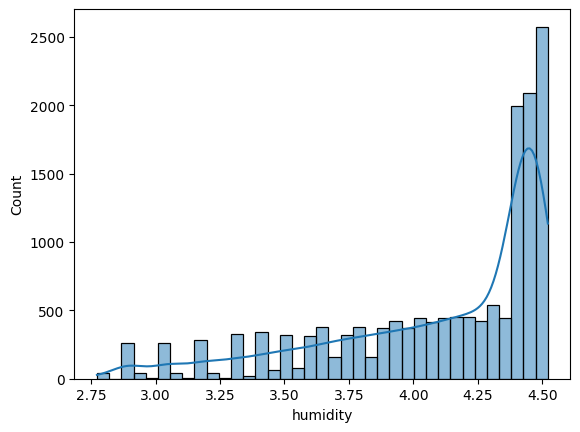

In [12]:
sns.histplot(np.log1p(df['humidity']), kde=True)
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


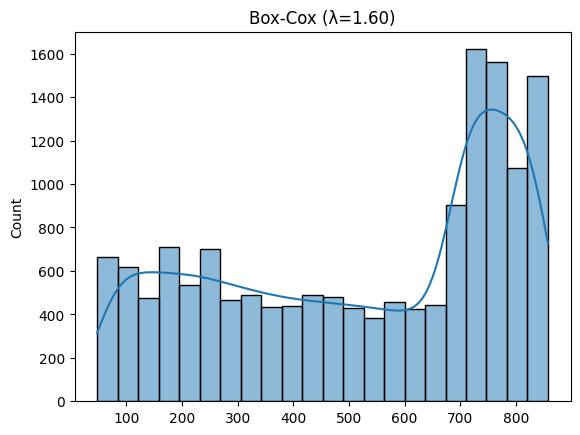

In [13]:
from scipy.stats import boxcox

humidity_bc, lam = boxcox(df['humidity'])
sns.histplot(humidity_bc, kde=True)
plt.title(f'Box-Cox (λ={lam:.2f})')
plt.show()

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


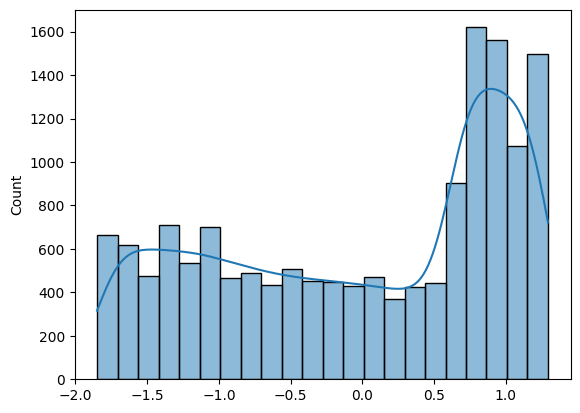

In [14]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
humidity_yj = pt.fit_transform(df[['humidity']])

sns.histplot(humidity_yj.flatten(), kde=True)
plt.show()


In [15]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
humidity_yj = pt.fit_transform(df[['humidity']])

df['humidity'] = humidity_yj.ravel()

In [16]:
from sklearn.preprocessing import StandardScaler , Normalizer , OneHotEncoder

In [17]:
ohe_cols = ['crop ID', 'soil_type', 'Seedling Stage']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[ohe_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=ohe_cols), encoded_df], axis=1)

In [18]:
df.head()

,MOI,temp,humidity,result,crop ID_Carrot,crop ID_Chilli,crop ID_Potato,crop ID_Tomato,crop ID_Wheat,soil_type_Alluvial Soil,...,soil_type_Red Soil,soil_type_Sandy Soil,Seedling Stage_Flowering,Seedling Stage_Fruit/Grain/Bulb Formation,Seedling Stage_Germination,Seedling Stage_Harvest,Seedling Stage_Maturation,Seedling Stage_Pollination,Seedling Stage_Seedling Stage,Seedling Stage_Vegetative Growth / Root or Tuber Development
0,1,25,0.670709,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,26,0.509228,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,27,0.351584,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,28,0.197834,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,29,0.048037,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [19]:
scaling_cols = ['temp']

scaler = StandardScaler()

df[scaling_cols] = scaler.fit_transform(df[scaling_cols])

In [20]:
df.head()

,MOI,temp,humidity,result,crop ID_Carrot,crop ID_Chilli,crop ID_Potato,crop ID_Tomato,crop ID_Wheat,soil_type_Alluvial Soil,...,soil_type_Red Soil,soil_type_Sandy Soil,Seedling Stage_Flowering,Seedling Stage_Fruit/Grain/Bulb Formation,Seedling Stage_Germination,Seedling Stage_Harvest,Seedling Stage_Maturation,Seedling Stage_Pollination,Seedling Stage_Seedling Stage,Seedling Stage_Vegetative Growth / Root or Tuber Development
0,1,-0.344172,0.670709,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,-0.241438,0.509228,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,-0.138704,0.351584,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,-0.035969,0.197834,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,0.066765,0.048037,1,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [21]:
X = df.drop(columns = ['result'])
y = df['result']

In [22]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [23]:
X_train.shape

(12231, 23)

In [25]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from catboost import CatBoostClassifier

In [26]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [27]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [28]:
# Create a function which can evaluate models and return a report
def evaluate_models(X , y , models):

    # Do the train test split
    X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

    models_list = []
    accuracy_list = []
    auc_list = []

    for i in range(len(list(models))):
        # extract the model object and model name
        model = list(models.values())[i]
        model_name = list(models.keys())[i]

        # do the train
        model.fit(X_train , y_train)

        # Do the prediction on training data
        y_train_pred = model.predict(X_train)
        # Do the prediction on test data
        y_test_pred = model.predict(X_test)

        # performance on training data
        model_train_accuracy, model_train_f1,model_train_precision,model_train_recall,model_train_rocauc_score = evaluate_clf(y_train ,y_train_pred)
        # performance on test data
        model_test_accuracy,model_test_f1,model_test_precision,model_test_recall,model_test_rocauc_score = evaluate_clf(y_test, y_test_pred)

        print(f"Model: {model_name}")
        models_list.append(model_name)

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1))
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc_list.append(model_test_rocauc_score)
        print('='*35)
        print('\n')

    # make the report
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)

    return report

In [29]:
base_model_report = evaluate_models(X = X , y = y , models = models)

Model: Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9997
- F1 score: 0.9996
- Precision: 0.9992
- Recall: 1.0000
- Roc Auc Score: 0.9997


Model: Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000


Model: Gradient Boosting
Model performance for Training set
- Accuracy: 0.9947
- F1 score: 0.9935
- Precision: 0.9881
- Recall: 0.9990
- Roc Auc Score: 0.9954
----------------------------------
Model performance for Test set
- Accuracy: 0.9902
- F1 score: 0.9880
- Precision: 0.9809
- Recall: 0.9951
- Roc Auc Score: 0.9910


Model: Logistic Regression
Mod

c:\Users\tipto\anaconda3\envs\micro\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: K-Neighbors Classifier
Model performance for Training set
- Accuracy: 0.9725
- F1 score: 0.9660
- Precision: 0.9753
- Recall: 0.9569
- Roc Auc Score: 0.9701
----------------------------------
Model performance for Test set
- Accuracy: 0.9451
- F1 score: 0.9315
- Precision: 0.9399
- Recall: 0.9232
- Roc Auc Score: 0.9416


Model: CatBoosting Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000


Model: Support Vector Classifier
Model performance for Training set
- Accuracy: 0.9120
- F1 score: 0.8843
- Precision: 0.9541
- Recall: 0.8240
- Roc Auc Score: 0.8984
----------------------------------
Model performance for Test set
- Accuracy: 0.9169
- F1 score: 0.8908
- Precision: 0.9513
- Recall: 0.8375
- Roc Auc Score: 0.9042


Mode

In [ ]:
base_model_report

In [30]:
model = RandomForestClassifier()
model.fit(X_train , y_train)

RandomForestClassifier()

In [31]:
y_pred = model.predict(X_test)
accuracy_score(y_test , y_pred)

0.9996729888816219

In [32]:
model.feature_importances_

array([0.34423587, 0.382845  , 0.21098453, 0.00175632, 0.00544489,
       0.00266652, 0.00163451, 0.00905575, 0.00090392, 0.00089975,
       0.00057905, 0.00148882, 0.00154587, 0.00104785, 0.00122376,
       0.00217686, 0.0026729 , 0.01205915, 0.00106053, 0.00208336,
       0.0054273 , 0.00477723, 0.00343029])

In [33]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [34]:
joblib.dump(ohe, "ohe.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pt, "pt.pkl")

['pt.pkl']

In [35]:
model = joblib.load("model.pkl")
ohe = joblib.load("ohe.pkl")
scaler = joblib.load("scaler.pkl")
pt = joblib.load("pt.pkl")

In [36]:
def predict_from_raw_input(raw_df: pd.DataFrame):
    """
    raw_df columns:
    ['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity']
    """

    df = raw_df.copy()

    # -------- 1. Power transform humidity --------
    df['humidity'] = pt.transform(df[['humidity']]).ravel()

    # -------- 2. One-hot encoding --------
    ohe_cols = ['crop ID', 'soil_type', 'Seedling Stage']
    encoded = ohe.transform(df[ohe_cols])

    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(ohe_cols),
        index=df.index
    )

    df = pd.concat([df.drop(columns=ohe_cols), encoded_df], axis=1)

    # -------- 3. Scale temperature --------
    df[['temp']] = scaler.transform(df[['temp']])

    # -------- 4. Prediction --------
    predictions = model.predict(df)

    return predictions

In [37]:
sample_input = pd.DataFrame({
    'crop ID': ['C001'],
    'soil_type': ['loamy'],
    'Seedling Stage': ['early'],
    'MOI': [0.45],
    'temp': [32.5],
    'humidity': [78.0]
})

pred = predict_from_raw_input(sample_input)
print(pred)

[1]
